# App Version Changelog Scraper — Revolut, Klarna, Wise (iOS)

Scrapes the **full version-history / changelog** ("What's New") for **Revolut**, **Klarna** and
**Wise** from the **Apple App Store**, filtered to the **past 12 months**.

**Why iOS-only?** Google Play exposes no per-version changelog history publicly (Android "What's New"
text only ever covers the latest update), so this notebook focuses on Apple, whose store front serves
the complete per-version history.

**Source.** The store's web app renders version history client-side via Apple's internal
`amp-api.apps.apple.com` endpoint, which requires a signed JWT bearer token. However, the store front
serves the **identical JSON** through a **token-free reverse proxy** at
`apps.apple.com/api/apps/v1/catalog/...`, so no token handling is required — a browser `User-Agent`
header is enough. Apple caps the history at **25 entries per app**.

**Environment.** Run with the `fintech-app-reviews` kernel (project venv). Only `requests`, `pandas` and
`matplotlib` are needed.


In [1]:
import html
import json
import os
import re
import time
from datetime import datetime, timedelta

import requests
import pandas as pd

pd.set_option("display.max_colwidth", 100)

## 1. Configuration

`MONTHS` sets the look-back window applied to each release date. `COUNTRY`/`LANG` are the Apple
storefront code and language — note the UK storefront code is **`gb`**, not `uk`. Per-app checkpoints
land in `data/raw/ios_<app>.csv` and the final combined dataset goes to `data/ios_changelogs.csv`.


In [2]:
MONTHS   = 12            # look-back window in months
COUNTRY  = "gb"          # Apple storefront code (UK = "gb", NOT "uk")
LANG     = "en-GB"
DATA_DIR = "data"
RAW_DIR  = os.path.join(DATA_DIR, "raw")
OUT_PATH = os.path.join(DATA_DIR, "ios_changelogs.csv")
SLEEP    = 0.5           # seconds between app requests

os.makedirs(RAW_DIR, exist_ok=True)

CUTOFF = datetime.now() - timedelta(days=int(365 * MONTHS / 12))
print("Keeping changelog entries released on/after", CUTOFF.date())

APPS = {
    "Revolut": 932493382,
    "Klarna":  1115120118,
    "Wise":    612261027,
}

for app, app_id in APPS.items():
    print(f"  {app}: iOS app id {app_id}")

Keeping changelog entries released on/after 2025-08-14
  Revolut: iOS app id 932493382
  Klarna: iOS app id 1115120118
  Wise: iOS app id 612261027


## 2. iOS version-history adapter

`fetch_ios_version_history(app_id)` GETs the token-free store-front proxy and returns the raw
`versionHistory` array. Each entry carries `externalVersionId`, `releaseDate`, `releaseNotes`,
`releaseTimestamp` and `versionDisplay`. A small retry loop (3 attempts, 5s apart) absorbs transient
network errors; if the `ios` platform block is missing the function returns `[]`.


In [ ]:
USER_AGENT = ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
              "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36")


def fetch_ios_version_history(app_id):
    url = (f"https://apps.apple.com/api/apps/v1/catalog/{COUNTRY}/apps/{app_id}"
           f"?platform=iphone&extend=versionHistory&l={LANG}")
    headers = {"User-Agent": USER_AGENT, "Accept": "application/json"}

    last_err = None
    for attempt in range(1, 4):
        try:
            r = requests.get(url, headers=headers, timeout=30)
            r.raise_for_status()
            attrs = r.json()["data"][0]["attributes"]["platformAttributes"]
            ios = attrs.get("ios")
            if ios is None:
                return []
            return ios.get("versionHistory", [])
        except requests.exceptions.RequestException as e:
            last_err = e
            print(f"  ! attempt {attempt}/3 failed: {e}")
            time.sleep(5)
    raise last_err

## 3. Normalisation & windowing

Maps the raw `versionHistory` entries into one tidy schema (`COLS`). `norm_ios()` is the per-entry
mapper; `load_existing()`/`save_progress()` provide the same resumable checkpoint behaviour as the
review scraper notebook (dedupe key = `(app, version)` tuple).


In [4]:
COLS = ["platform", "app", "version", "release_date", "release_notes",
        "external_version_id", "scraped_at"]


def norm_ios(app, v):
    return {
        "platform": "app_store",
        "app": app,
        "version": v.get("versionDisplay"),
        "release_date": v.get("releaseDate"),
        "release_notes": v.get("releaseNotes"),
        "external_version_id": v.get("externalVersionId"),
        "scraped_at": datetime.now().isoformat(timespec="seconds"),
    }


def load_existing(path):
    """Return (rows, seen_versions) from a previously saved checkpoint CSV."""
    if os.path.exists(path) and os.path.getsize(path) > 0:
        df = pd.read_csv(path)
        if len(df):
            seen = set(zip(df["app"], df["version"].astype(str)))
            return df.to_dict("records"), seen
    return [], set()


def save_progress(path, rows):
    pd.DataFrame(rows, columns=COLS).to_csv(path, index=False)

## 4. Run the scraper

One request per app (3 total) — the store-front proxy caps version history at 25 entries. Entries are
kept only when `releaseDate >= CUTOFF.date()`, which is a plain string comparison on the `YYYY-MM-DD`
date. Checkpoints are written to `data/raw/ios_<app>.csv` so a re-run resumes instead of duplicating.


In [5]:
all_rows = []
for app, app_id in APPS.items():
    path = os.path.join(RAW_DIR, f"ios_{app}.csv")
    rows, seen = load_existing(path)

    history = fetch_ios_version_history(app_id)
    kept = []
    for v in history:
        release_date = v.get("releaseDate") or ""
        if release_date < str(CUTOFF.date()):
            continue
        key = (app, v.get("versionDisplay"))
        if key in seen:
            continue
        seen.add(key)
        kept.append(norm_ios(app, v))

    rows.extend(kept)
    save_progress(path, rows)
    print(f"[{app}] fetched {len(history)}, kept {len(kept)}")

    all_rows.extend(rows)
    time.sleep(SLEEP)

print(f"\nCollected {len(all_rows)} rows total")

[Revolut] fetched 25, kept 0
[Klarna] fetched 25, kept 0
[Wise] fetched 25, kept 0

Collected 75 rows total


## 5. Combine, clean and save

Concats the per-app checkpoints into one DataFrame, parses `release_date`, drops anything before the
cutoff, removes duplicate `(app, version)` pairs, sorts by app then release date, and writes the final
CSV to `data/ios_changelogs.csv`.


In [6]:
frames = []
for app in APPS:
    path = os.path.join(RAW_DIR, f"ios_{app}.csv")
    if os.path.exists(path) and os.path.getsize(path) > 0:
        frames.append(pd.read_csv(path))

df = pd.concat(frames, ignore_index=True)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
df = df[df["release_date"] >= pd.Timestamp(CUTOFF.date())]
df = df.drop_duplicates(subset=["app", "version"]).reset_index(drop=True)
df = df.sort_values(["app", "release_date"], ignore_index=True)

df.to_csv(OUT_PATH, index=False)
print(f"Saved {len(df)} rows to {OUT_PATH}")

Saved 75 rows to data/ios_changelogs.csv


## 6. Quick overview

Summary statistics: releases per app, the total, and the actual date span covered by the dataset.


In [7]:
print("=== Releases per app ===")
print(df.groupby("app", observed=True).size().to_string())
print("\n=== Total releases ===")
print(len(df))
print("\n=== Date range ===")
print("Earliest:", df["release_date"].min().date(), "| Latest:", df["release_date"].max().date())
print("\n=== Preview ===")
display(df.head(10))

=== Releases per app ===
app
Klarna     25
Revolut    25
Wise       25

=== Total releases ===
75

=== Date range ===
Earliest: 2026-03-19 | Latest: 2026-08-14

=== Preview ===


,platform,app,version,release_date,release_notes,external_version_id,scraped_at
0,app_store,Klarna,26.11.311,2026-03-19,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",883355934,2026-08-14T13:24:35
1,app_store,Klarna,26.12.297,2026-03-25,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",883590544,2026-08-14T13:24:35
2,app_store,Klarna,26.13.306,2026-04-01,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",883842848,2026-08-14T13:24:35
3,app_store,Klarna,26.14.277,2026-04-07,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",884057157,2026-08-14T13:24:35
4,app_store,Klarna,26.15.157,2026-04-14,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",884371066,2026-08-14T13:24:35
5,app_store,Klarna,26.16.229,2026-04-20,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",884638987,2026-08-14T13:24:35
6,app_store,Klarna,26.17.250,2026-04-27,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",884898480,2026-08-14T13:24:35
7,app_store,Klarna,26.18.243,2026-05-04,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",885160978,2026-08-14T13:24:35
8,app_store,Klarna,26.19.213,2026-05-11,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",885438075,2026-08-14T13:24:35
9,app_store,Klarna,26.20.259,2026-05-18,"The Klarna app puts you in control of your payments, making it easy to manage every purchase in ...",885726442,2026-08-14T13:24:35


## 7. Chart — release cadence by app

For each app, the **cumulative count of releases over time** — a step plot whose height at any date
equals the number of versions shipped up to that point. Steeper lines mean faster shipping; the flats
between steps are the release gaps.


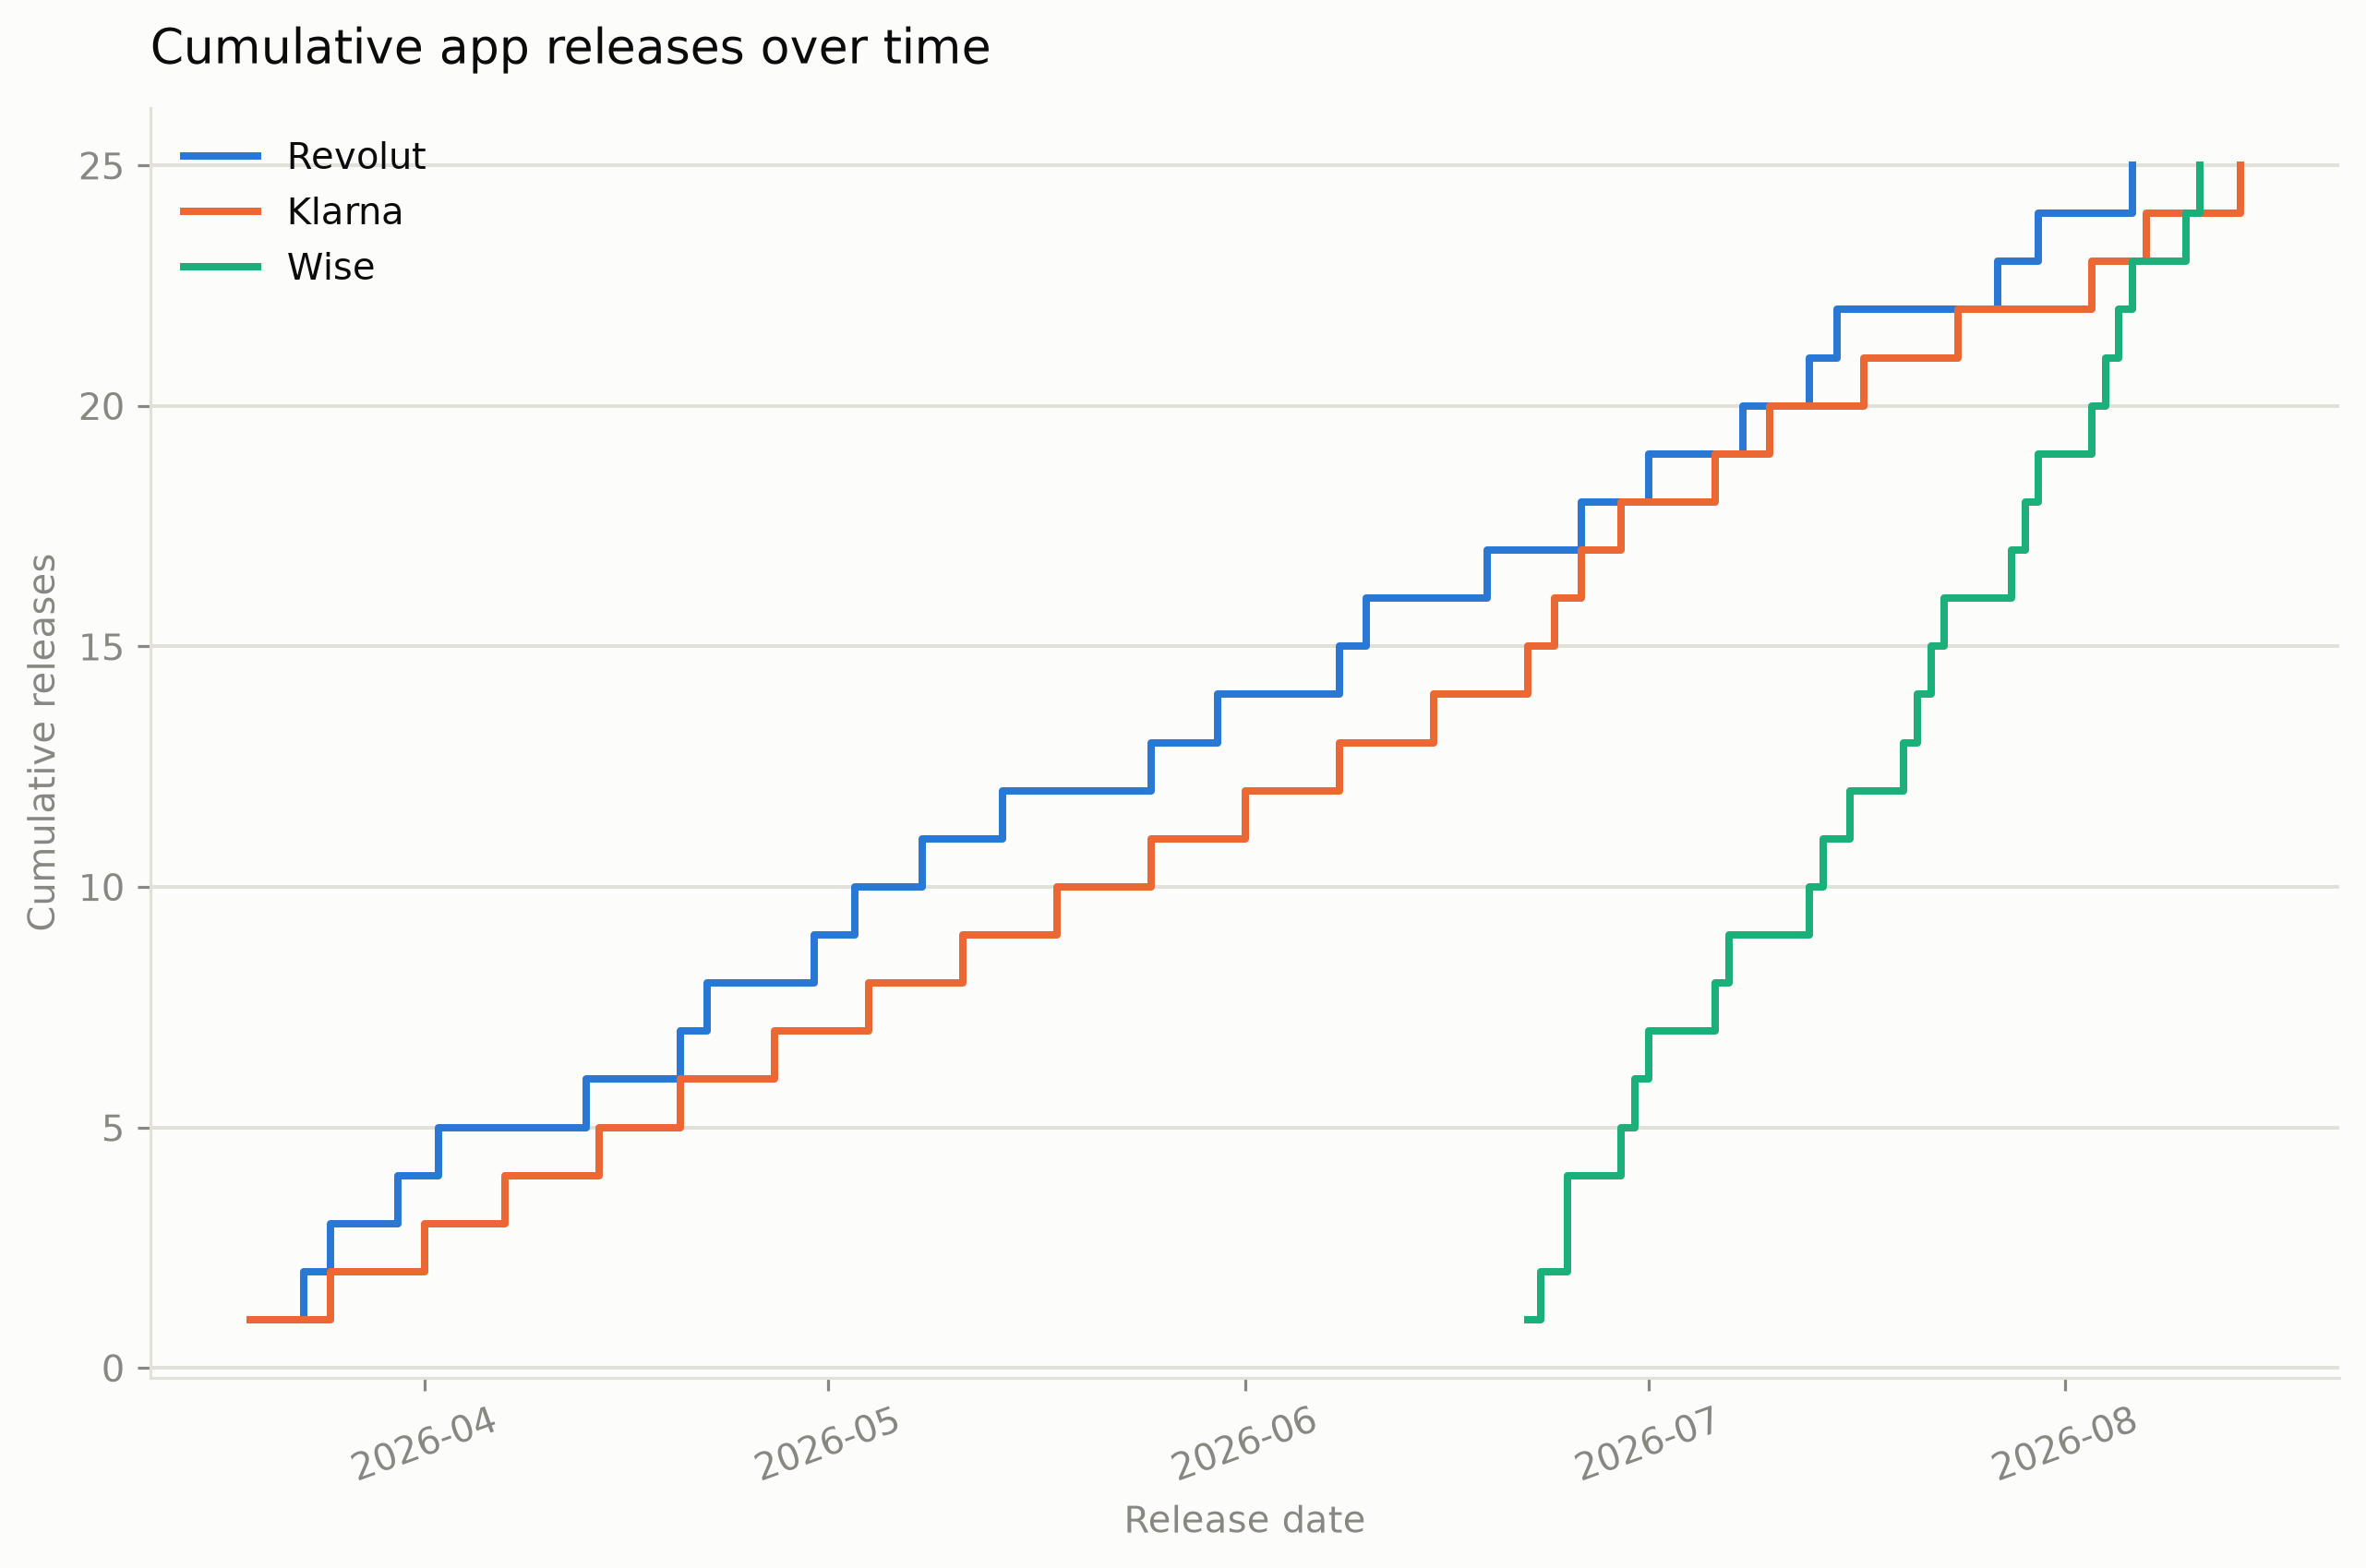

In [8]:
import matplotlib.pyplot as plt

APP_COLORS = {"Revolut": "#2a78d6", "Klarna": "#eb6834", "Wise": "#1baf7a"}
INK      = "#0b0b0b"
MUTED    = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE  = "#fcfcfb"

if df.empty:
    print("No data to plot — run the scraper cells above first.")
else:
    fig, ax = plt.subplots(figsize=(9, 6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    for app in APPS:
        sub = df[df["app"] == app].sort_values("release_date")
        ax.step(sub["release_date"], range(1, len(sub) + 1), where="post",
                color=APP_COLORS[app], label=app, linewidth=2)

    ax.set_xlabel("Release date", color=MUTED, fontsize=10)
    ax.set_ylabel("Cumulative releases", color=MUTED, fontsize=10)
    ax.tick_params(axis="x", colors=MUTED, rotation=20)
    ax.tick_params(axis="y", colors=MUTED)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.spines["left"].set_color(GRIDLINE)

    ax.set_title("Cumulative app releases over time", color=INK, fontsize=13, loc="left", pad=12)
    ax.legend(frameon=False, labelcolor=INK)

    plt.tight_layout()
    plt.show()